## Welcome to the Planetary Data Reader Example Jupyter Notebook!

The Planetary Data Reader (`pdr`) is a Python package that provides a single, straightforward interface to planetary science observational data. It is currently under active development and will eventually support almost all data hosted by the Planetary Data System (PDS). The basic command is: `pdr.read(fn)`, where `fn` is either an observational data file or its detached label file (if one exists).

This notebook demonstrates basic usage and key features of `pdr`.

_**Note:** This notebook downloads data from the PDS, so it requires an internet connection. You do not need an internet connection to use `pdr` with data that is already on your computer._

In [2]:
# glob, os, and requests are used to check paths and retrieve remote data in this notebook. you do 
# not need to import them for most uses of pdr.
import glob
import os
# If you're running this locally (not on binder) you'll need to install `requests`. You can do this by activating your
# conda environment and running 'conda install requests', or if you use pip running 'pip install requests' in a terminal
import requests

# importing the pdr module itself is mandatory for most uses of pdr.
import pdr

example files to find:
- table?
- product with multiple pointers (show how only loaded objects are dumped)
- single band image (maybe; we already give an example of that in Example_Jupyter_Notebook)
- rgb(a) multiband image
  - band_ix
  - override_rgb
  - mask_color
  - scaled vs unscaled
  - image_clip
- maybe a >4 band image, but can demonstrate same things with the rgb example
- multiband image with unusual axes to slice

- rgba multiband image:
    - http://pdssbn.astro.umd.edu/holdings/nh-p_psa-leisa_mvic-5-comp-v1.0/data/color
    - mvic_0299147977_0x545_sci_pl.img


In [74]:
# These are URLs for New Horizons MVIC data and label files
nh_url = 'http://pdssbn.astro.umd.edu/holdings/nh-p_psa-leisa_mvic-5-comp-v1.0/data/color/mvic_0299147977_0x545_sci_pl.img'
nh_lbl = 'http://pdssbn.astro.umd.edu/holdings/nh-p_psa-leisa_mvic-5-comp-v1.0/data/color/mvic_0299147977_0x545_sci_pl.lbl'
# This downloads the data to the current working directory, same way as in Example_JupyterNotebook.ipynb
nh_fn = nh_url.split('/')[-1]
if not os.path.exists(nh_fn):
    req = requests.get(nh_url)
    open(nh_fn, 'wb').write(req.content)
nh_lbl_fn = nh_lbl.split('/')[-1]
if not os.path.exists(nh_lbl):
    reqlbl = requests.get(nh_lbl)
    open(nh_lbl_fn, 'wb').write(reqlbl.content)

In [76]:
# read the file
pluto_multiband = pdr.read(nh_lbl_fn)

# remember dump_browse only works on loaded objects. See that none of the keys/pointers are loaded yet:
pluto_multiband

pdr.Data(/Users/sabrinacurtis/Documents/GitHub/pdr/mvic_0299147977_0x545_sci_pl.lbl)
keys=['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']
not yet loaded: ('LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION')

In [77]:
# load the IMAGE pointer
pluto_multiband["IMAGE"]

array([[[-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        ...,
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38]],

       [[-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, -3.4028227e+38, -3.4028227e+38, ...,
         -3.4028227e+38, -3.4028227e+38, -3.4028227e+38],
        [-3.4028227e+38, 

In [78]:
# check that the IMAGE pointer has been loaded. Yep! It's ready for dump_browse now
pluto_multiband

pdr.Data(/Users/sabrinacurtis/Documents/GitHub/pdr/mvic_0299147977_0x545_sci_pl.lbl)
keys=['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']
not yet loaded: ('LABEL', 'DATA_SET_MAP_PROJECTION')

In [ ]:
# prefix


In [ ]:
# outpath


In [ ]:
# scaled


In [ ]:
# purge


show and dump_browse accept the same optional browse_kwargs

The keys are ['LABEL', 'IMAGE', 'DATA_SET_MAP_PROJECTION']


/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:330: UserWarning: transparency not supported, removing 4th (alpha) channel
  warnings.warn(


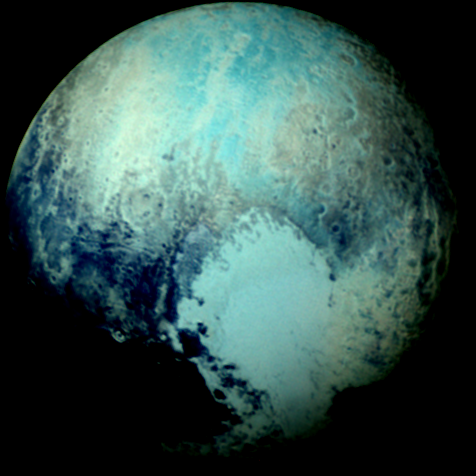

In [68]:
data = pdr.read("/Users/sabrinacurtis/Documents/GitHub/pdr-tests/pdr_tests/data/nh_derived/color_img/mvic_0299147977_0x545_sci_pl.lbl")
print(f'The keys are {data.keys()}')

data.show("IMAGE", mask_color=(0, 0, 0), image_clip=(25, 0)) # clip=(low_percentile, 100-high_percentile)

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:350: UserWarning: band_ix=4 does not exist, dumping band 2
  warnings.warn(


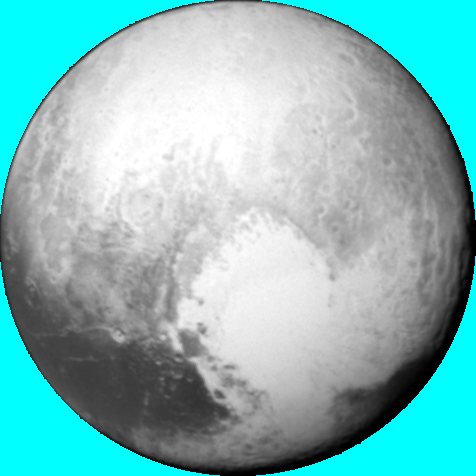

In [66]:
data.show("IMAGE", override_rgba=True, band_ix=4)

In [65]:
data.show("IMAGE", override_rgba=True, slice_axis=1)

/Users/sabrinacurtis/Documents/GitHub/pdr/pdr/browsify.py:344: UserWarning: dumping only band 238 of this image
  warnings.warn(f"dumping only band {middle_ix} of this image")


attempt to dump all data objects associated with this Data object
to disk.

By default, writes files to the working directory.

By default, assigns filenames like:
{filename stem}_{object name}.{file extension}

So, for instance, a browse version of a TABLE object referenced from
"jn23a1.lbl" would be written to  "jn23a1_TABLE.csv".

If prefix is not None, filenames will begin with the value of prefix
rather than the original filename stem.

If outpath is not None, files will be written to the value of outpath
rather than to the working directory.

By default, attempts to apply scaling/offset factors and special
constant masking before writing images. If scaled is False, does not
do that. If scaled == "both", writes both scaled and unscaled
versions, adding "_scaled" and "_unscaled" to their respective
filenames before the file extension. Note that some types of load
operations (like for FITS files) may have already applied scaling
factors, in which case recovering the unscaled image is not possible.

if purge is True, objects are deleted as soon as they are dumped,
rendering this Data object 'empty' afterward.

**browse_kwargs are passed directly to browsify.browsify(), and
offer various ways to modify image dumping behavior:

- image_clip: Union[float, tuple[float, float], None] = None
    Applies a percentile clip to the image at
    clip = (low_percentile, 100-high_percentile).
    If clip is a single value, low_percentile=high_percentile
    in the above formula. If it's a tuple, low_percentile is
    the first value in the tuple.

    The default None value causes 'nice' clipping: it clips the image
    at (1, 1), but if this results in the clipped image containing only
    a single value, it uses the original image instead. Pass 0 if
    absolutely no clipping is desired.

- mask_color: Optional[tuple[int, int, int]] = (0, 255, 255)
    Allows specification of RGB color for masked arrays (default cyan)

- band_ix: Optional[int] = None
    The index of the band to be exported in a multiband image. If None,
    the middle band of the image is exported. If there are 3-4 bands in
    the image and the override_rgba argument is False, this value is
    ignored.

    When set equal to "burst", returns a separate browse product for
    each band of a multiband image, appending numbers to the filenames
    prior to the file extension.

- save: bool = True
    If False, renders images in memory but does not save them to disk.
    Not generally useful when passed to this method except for testing.

- override_rgba: bool = False
    Allows use of band_ix when there are 3-4 bands in the image.
    Otherwise, the image will be returned as a stacked rgb image
    (the assumed 'alpha' channel is always dropped). Setting this to
    True is useful when a 3/4 band image is not actually RGB(A) (e.g.
    XYZ spatial products).

    This argument has no effect on images that do not have 3-4 bands.

- image_format: str = "jpg"
    Sets image extension which informs the format pillow will save the
    browse image as.

- slice_axis: int = 0
    Allows specification of which axis to slice along for the
    dump_browse image. The default slices at axis 0 (which is usually
    the axis labelled "BAND").